# Citi Bike Data Engineering Project


## Project Overview
Design and implement a normalised PostgreSQL database that integrates 2016 Citi Bike trip data with Newark Airport weather data, complete with a robust ETL pipeline and analytical views.

## Imported Libraries

In [56]:
# DataFlow-Pro Library (Main)
import dataflow_pro as dfp
from dataflow_pro.core import DataLoader, DataFrameWrapper
from dataflow_pro.eda import (
    comprehensive_quality_assessment,
    generate_stacked_report
)
from dataflow_pro.schema import (
    design_schema_definition,
    RelationshipMatch
)
from dataflow_pro.schema.schema_reporter import EnhancedSchemaReporter, SchemaReportConfig


from dataflow_pro.schema.model import (
    generate_postgresql_ddl,
    generate_pattern_aware_postgresql_ddl
)
from dataflow_pro.rules import (
    create_comprehensive_rule_set,
    RuleValidator,
    ValidationReportIntegrator,
    RuleGenerator
)
from dataflow_pro.pipeline import (
    PipelineBuilder,
    PipelineConfig,
    PipelineMonitor,
    PipelineType,
    SchemaModel,
    create_monitoring_pipeline
)

# Standard Library
import os
import sys
from pathlib import Path
from datetime import datetime, timedelta
import json
import warnings

# Environment and Configuration
from dotenv import load_dotenv

# Data Processing
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import polars as pl
import duckdb

# Database Connectivity
import psycopg_binary as psycopg
from sqlalchemy import create_engine, text, inspect
from sqlalchemy.engine import Engine

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Utilities
from tqdm import tqdm
import warnings

# Configure Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Environment Setup

In [27]:
# Declare the report directory
REPORT_DIR = Path("reports")
REPORT_DIR.mkdir(exist_ok=True)

# Load environment variables
load_dotenv()

# Database configuration
DB_CONFIG = {
    'host': os.getenv('DB_HOST', 'localhost'),
    'port': os.getenv('DB_PORT', '5432'),
    'database': os.getenv('DB_NAME', 'citibike_db'),
    'user': os.getenv('DB_USER', 'postgres'),
    'password': os.getenv('DB_PASSWORD', 'postgres6789')
}

# Create connection string
CONNECTION_STRING = f"postgresql+psycopg://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"

print("✓ Environment setup complete!")
print(f"✓ Database: {DB_CONFIG['database']}")
print(f"✓ Host: {DB_CONFIG['host']}:{DB_CONFIG['port']}")
print(f"✓ SQLAlchemy and psycopg-binary ready for database operations")

✓ Environment setup complete!
✓ Database: citibike_db
✓ Host: localhost:5432
✓ SQLAlchemy and psycopg-binary ready for database operations


## Task 1: Data Preparation
### Load Data Using Core Module

In [28]:
# Define data directory
data_dir = Path('data-sources/data')

print(f"Data directory: {data_dir}")

# List available files
if data_dir.exists():
    print(f"\nFiles in {data_dir}:")
    for file in data_dir.iterdir():
        if file.is_file():
            print(f"  - {file.name}")

# Load Citi Bike CSV files using dataflow-pro
citibike_files = [
    'JC-201601-citibike-tripdata.csv',
    'JC-201602-citibike-tripdata.csv',
    'JC-201603-citibike-tripdata.csv',
    'JC-201604-citibike-tripdata.csv',
    'JC-201605-citibike-tripdata.csv',
    'JC-201606-citibike-tripdata.csv',
    'JC-201607-citibike-tripdata.csv',
    'JC-201608-citibike-tripdata.csv',
    'JC-201609-citibike-tripdata.csv',
    'JC-201610-citibike-tripdata.csv',
    'JC-201611-citibike-tripdata.csv',
    'JC-201612-citibike-tripdata.csv'
]

print("\nLoading Citi Bike trip data using DataLoader...")

# Load all files directly as Arrow tables
tables = []
target_schema = None

for i, file in enumerate(citibike_files):
    try:
        table = DataLoader().load_csv_to_arrow(data_dir / file)

        # Use the first table's schema as the target schema
        if target_schema is None:
            target_schema = table.schema
            print(f"✓ Using schema from {file} as target schema")

        # Cast the table to match the target schema
        if table.schema != target_schema:
            print(f"Schema mismatch in {file} - casting to target schema")
            table = table.cast(target_schema)

        tables.append(table)
        print(f"Loaded {file}: {len(table):,} rows")

    except Exception as e:
        print(f"Failed to load {file}: {e}")

# Concatenate tables with consistent schemas
if tables:
    combined = pa.concat_tables(tables)
    print(f"\nSuccessfully concatenated {len(tables)} tables")
    print(f"Combined table shape: {combined.shape}")
    print(f"Schema: {combined.schema}")

    # Wrap in DataFrameWrapper
    trips_data = dfp.DataFrameWrapper(combined)
    print(f"Wrapped in DataFrameWrapper")
else:
    print("No tables loaded successfully")
    trips_data = None

# Step 2: Load weather data
weather_file = 'newark_airport_2016.csv'
weather_path = data_dir / weather_file

print(f"\nLoading weather data...")
if weather_path.exists():
    try:
        weather_data = dfp.load(weather_path)
        print(f"Weather records loaded: {len(weather_data):,}")
        print(f"Weather columns: {weather_data.columns}")

    except Exception as e:
        print(f"Failed to load weather data: {e}")
        weather_data = None
else:
    print(f"Weather file not found: {weather_path}")
    weather_data = None

# Store both datasets for further processing
datasets = {
    'citibike_trips': trips_data,
    'weather': weather_data
}

print(f"\nData loading summary:")
print(f"  • Citi Bike trips: {'✓ Loaded' if trips_data is not None else '❌ Failed'}")
print(f"  • Weather data: {'✓ Loaded' if weather_data is not None else '❌ Failed'}")

Data directory: data-sources/data

Files in data-sources/data:
  - JC-201602-citibike-tripdata.csv
  - JC-201608-citibike-tripdata.csv
  - newark_airport_2016.csv
  - JC-201606-citibike-tripdata.csv
  - JC-201610-citibike-tripdata.csv
  - JC-201604-citibike-tripdata.csv
  - JC-201612-citibike-tripdata.csv
  - JC-201603-citibike-tripdata.csv
  - JC-201609-citibike-tripdata.csv
  - JC-201601-citibike-tripdata.csv
  - JC-201611-citibike-tripdata.csv
  - JC-201607-citibike-tripdata.csv
  - JC-201605-citibike-tripdata.csv

Loading Citi Bike trip data using DataLoader...
✓ Using schema from JC-201601-citibike-tripdata.csv as target schema
Loaded JC-201601-citibike-tripdata.csv: 7,479 rows
Loaded JC-201602-citibike-tripdata.csv: 8,250 rows
Loaded JC-201603-citibike-tripdata.csv: 13,511 rows
Loaded JC-201604-citibike-tripdata.csv: 16,342 rows
Loaded JC-201605-citibike-tripdata.csv: 19,488 rows
Loaded JC-201606-citibike-tripdata.csv: 23,947 rows
Loaded JC-201607-citibike-tripdata.csv: 24,436 ro

## Task 2: Data Quality Assessment
### Generate Data Quality Assessment Report

In [29]:
# Setup the report path and title
REPORT_PATH = REPORT_DIR / "citibike_data_quality_assessment.html"
REPORT_TITLE = "Data Quality Assessment - Comprehensive Analysis"

# Run quality assessment on each dataset
print("\n" + "="*60)
print("DATA QUALITY & EDA ASSESSMENT")
print("="*60)

quality_reports = {}
cleaned_datasets = {}
failed_tables = []

for table_name, data_wrapper in datasets.items():
    try:
        report = comprehensive_quality_assessment(
            data_wrapper
        )

        quality_reports[table_name] = report
        cleaned_datasets[table_name] = data_wrapper

        print(f"   Quality Score: {report.overall_score:.1f}%")
        print(f"   Rows: {report.total_rows:,} - Columns: {report.total_columns}")
        print(f"   Issues: {len(report.issues)} ({report.critical_issues} critical)")

    except Exception as e:
        print(f"   Initial assessment failed: {e}")

# Generate HTML report that displays the results from the data quality assessments
print("\n" + "="*60)
print("GENERATING HTML REPORT")
print("="*60)

if cleaned_datasets:
    try:
        print(f"\n Generating stacked report for {len(cleaned_datasets)} tables...")

        report_path = generate_stacked_report(
            datasets=cleaned_datasets,
            output_path=REPORT_PATH,
            title=REPORT_TITLE
        )

        print(f" Report generated: {report_path}")

    except Exception as e:
        print(f"  Report generation failed: {e}")
else:
    print(" No successful assessments - cannot generate report")

# Display a summary of the assessments within the cell output
print("\n" + "="*60)
print(" ASSESSMENT COMPLETE")
print("="*60)

total_tables = len(datasets)
successful_tables = len(quality_reports)
failed_count = len(failed_tables)

print(f"\n Overall Summary:")
print(f"  - Total Tables: {total_tables}")
print(f"  - Successful: {successful_tables}")
print(f"  - Failed: {failed_count}")

if quality_reports:
    avg_score = sum(r.overall_score for r in quality_reports.values()) / len(quality_reports)
    total_critical = sum(r.critical_issues for r in quality_reports.values())
    total_warnings = sum(r.warning_issues for r in quality_reports.values())
    total_issues = sum(len(r.issues) for r in quality_reports.values())

    print(f"\n Quality Metrics:")
    print(f"  - Average Quality Score: {avg_score:.1f}%")
    print(f"  - Total Issues: {total_issues}")
    print(f"  - Critical Issues: {total_critical}")
    print(f"  - Warnings: {total_warnings}")

    print(f"\n Per-Table Results:")
    for table_name, report in quality_reports.items():
        score = report.overall_score
        status = "" if score >= 90 else " " if score >= 70 else "-"
        print(f"  {status} {table_name}: {score:.1f}% "
              f"({len(report.issues)} issues, {report.critical_issues} critical)")

if failed_tables:
    print(f"\n Failed Tables:")
    for table_info in failed_tables:
        print(f" {table_info['name']}")
        print(f"    Error: {table_info['error']}")

if quality_reports:
    print(f"\n Full report: {REPORT_PATH}")

print("\n Data quality assessments complete")
print(" EDA reports generated in 'reports/' folder")


DATA QUALITY & EDA ASSESSMENT
   Quality Score: 0.0%
   Rows: 247,584 - Columns: 15
   Issues: 25 (0 critical)
   Quality Score: 0.0%
   Rows: 366 - Columns: 16
   Issues: 23 (2 critical)

GENERATING HTML REPORT

 Generating stacked report for 2 tables...
   Quality Score: 0.0%
   Rows: 247,584 - Columns: 15
   Issues: 25 (0 critical)
   Quality Score: 0.0%
   Rows: 366 - Columns: 16
   Issues: 23 (2 critical)

GENERATING HTML REPORT

 Generating stacked report for 2 tables...
 Report generated: reports/citibike_data_quality_assessment.html

 ASSESSMENT COMPLETE

 Overall Summary:
  - Total Tables: 2
  - Successful: 2
  - Failed: 0

 Quality Metrics:
  - Average Quality Score: 0.0%
  - Total Issues: 48
  - Critical Issues: 2
  - Warnings: 33

 Per-Table Results:
  - citibike_trips: 0.0% (25 issues, 0 critical)
  - weather: 0.0% (23 issues, 2 critical)

 Full report: reports/citibike_data_quality_assessment.html

 Data quality assessments complete
 EDA reports generated in 'reports/'

## Task 3: Business Rule Validation
### Create a series of rules to validate against the dataset

In [30]:
# Setup the report path and title
REPORT_PATH = REPORT_DIR / "citibike_rule_validation_assessment.html"
REPORT_TITLE = "Data Validation & Business Rules Assessment"

# Define custom business rules based on data dictionary
custom_business_rules_1 = [
    {
        'rule_type': 'datetime_range',
        'table': 'citibike_trips',
        'columns': ['Start Time', 'Stop Time'],
        'parameters': {
            'min_date': datetime(2016, 1, 1),
            'max_date': datetime(2016, 12, 31, 23, 59, 59)
        },
        'severity': 'error',
        'description': 'Trip timestamps must be within the year 2016'
    },
    {
        'rule_type': 'not_null',
        'table': 'citibike_trips',
        'columns': ['Start Station ID', 'End Station ID', 'Bike ID'],
        'severity': 'error',
        'description': 'Start Station ID, End Station ID, and Bike ID are mandatory'
    },
    {
        'rule_type': 'numeric_range',
        'table': 'citibike_trips',
        'columns': ['Start Station Latitude', 'End Station Latitude'],
        'parameters': {40.0: 41.0},  # Example lat range for NJ
        'severity': 'warning',
        'description': 'Latitude must be within the range of 40.0 to 41.0'
    },
    {
        'rule_type': 'numeric_range',
        'table': 'citibike_trips',
        'columns': ['Start Station Longitude', 'End Station Longitude'],
        'parameters': {-75.0: -73.0},  # Example long range for NJ
        'severity': 'warning',
        'description': 'Longitude must be within the range of -75.0 to -73.0'
    },
    {
        'rule_type': 'categorical_enum',
        'table': 'citibike_trips',
        'columns': ['User Type'],
        'parameters': {
            'allowed_values': ['Customer', 'Subscriber']
        },
        'severity': 'warning',
        'description': 'User Type must be either Customer or Subscriber'
    },
    {
        'rule_type': 'categorical_enum',
        'table': 'citibike_trips',
        'columns': ['Gender'],
        'parameters': {
            'allowed_values': [0, 1, 2]
        },
        'severity': 'warning',
        'description': 'Gender must be either 0 (Unknown), 1 (Male), or 2 (Female)'
    },
    {
        'rule_type': 'numeric_range',
        'table': 'citibike_trips',
        'columns': ['Birth Year'],
        'parameters': {1940: 2000},
        'severity': 'warning',
        'description': 'Birth Year must be within the range of 1940 to 2000'
    },
    {
        'rule_type': 'datetime_range',
        'table': 'weather',
        'columns': ['DATE'],
        'parameters': {
            'min_date': datetime(2016, 1, 1),
            'max_date': datetime(2016, 12, 31, 23, 59, 59)
        },
        'severity': 'error',
        'description': 'Weather dates must be within the year 2016'
    }
]
print("\n" + "="*70)
print("RULES VALIDATION & ASSESSMENT")
print("="*70)

print(f"\nGenerating custom business rules for {len(datasets)} tables...")

try:
    # Initialize rule generator
    rule_generator = RuleGenerator()

    # Generate rules from custom specifications
    all_rules = rule_generator.create_business_rules(custom_business_rules_1)

    print(f"Generated {len(all_rules)} validation rules")

    # Run validation
    print(f"\nValidating {len(datasets)} tables against {len(all_rules)} rules...")
    validator = RuleValidator()
    validation_summary = validator.validate_all(datasets, all_rules)

    print(f"Validation complete!")
    print(f"\nValidation Results:")
    print(f"  - Total Rules: {validation_summary.total_rules}")
    print(f"  - Passed: {validation_summary.passed_rules}")
    print(f"  - Failed: {validation_summary.failed_rules}")
    print(f"  - Quality Score: {validation_summary.data_quality_score:.1f}%")
    print(f"  - Total Violations: {validation_summary.total_violations}")

    print(f"\nCreating validation report using dataflow-pro...")

    # Use ValidationReportIntegrator to generate complete HTML report
    integrator = ValidationReportIntegrator()

    # Generate standalone validation HTML report
    # This uses the built-in method that creates a complete HTML document
    report_html = integrator.generate_validation_html_section(validation_summary)

    # Write directly to file
    with open(REPORT_PATH, 'w', encoding='utf-8') as f:
        f.write(report_html)

    print(f"Report generated: {REPORT_PATH}")

    print("\n" + "="*70)
    print("VALIDATION COMPLETE")
    print("="*70)

    print(f"\nSummary:")
    print(f"  - Tables Validated: {len(datasets)}")
    print(f"  - Total Rules: {len(all_rules)}")
    print(f"  - Pass Rate: {(validation_summary.passed_rules / validation_summary.total_rules * 100):.1f}%")
    print(f"  - Quality Score: {validation_summary.data_quality_score:.1f}%")

    if validation_summary.failed_rules > 0:
        print(f"\n{validation_summary.failed_rules} rule(s) failed - Review the HTML report")

    print(f"\nFull report: {REPORT_PATH}")

except Exception as e:
    print(f"\nValidation failed: {e}")
    import traceback
    traceback.print_exc()


RULES VALIDATION & ASSESSMENT

Generating custom business rules for 2 tables...
Generated 8 validation rules

Validating 2 tables against 8 rules...
Validation complete!

Validation Results:
  - Total Rules: 8
  - Passed: 5
  - Failed: 1
  - Quality Score: 54.5%
  - Total Violations: 380

Creating validation report using dataflow-pro...
Report generated: reports/citibike_rule_validation_assessment.html

VALIDATION COMPLETE

Summary:
  - Tables Validated: 2
  - Total Rules: 8
  - Pass Rate: 62.5%
  - Quality Score: 54.5%

1 rule(s) failed - Review the HTML report

Full report: reports/citibike_rule_validation_assessment.html


In [31]:
# Investigate the violations for the 'citibike_trips' table
if 'citibike_trips' in validation_summary.results_by_table:
    validation_results = validation_summary.results_by_table['citibike_trips']
    print(f"\nValidation results for 'citibike_trips': {len(validation_results)}")

    # Count violations by extracting from validation results
    violations_count = 0
    violation_summary = {}

    for result in validation_results:
        if not result.passed:  # If the rule failed
            violations_count += result.violations_count if hasattr(result, 'violations_count') else 1
            rule_desc = result.rule_description
            if rule_desc not in violation_summary:
                violation_summary[rule_desc] = 0
            violation_summary[rule_desc] += result.violations_count if hasattr(result, 'violations_count') else 1

    print(f"Total violations in 'citibike_trips': {violations_count}")

    if violation_summary:
        print("\nViolation Summary by Rule:")
        for rule, count in violation_summary.items():
            print(f"  - {rule}: {count} violation(s)")

        # Display sample violation details
        print("\nSample Failed Validation Results:")
        failed_results = [r for r in validation_results if not r.passed]
        for result in failed_results[:5]:  # Show first 5 failed results
            print(f"  - Rule: {result.rule_description}")
            print(f"    Status: {result.status}")
            print(f"    Description: {result.rule_description}")
            if hasattr(result, 'violations_count'):
                print(f"    Violations: {result.violations_count}")
            print()
else:
    print("\nNo validation results found for 'citibike_trips' table")


Validation results for 'citibike_trips': 7
Total violations in 'citibike_trips': 2

Violation Summary by Rule:
  - Trip timestamps must be within the year 2016: 1 violation(s)
  - User Type must be either Customer or Subscriber: 1 violation(s)

Sample Failed Validation Results:
  - Rule: Trip timestamps must be within the year 2016
    Status: skipped
    Description: Trip timestamps must be within the year 2016

  - Rule: User Type must be either Customer or Subscriber
    Status: failed
    Description: User Type must be either Customer or Subscriber



## Task 4: Data Transformation
### Using the results from the Data Quality Assessment and Business Rule Validation to transform the raw data into the 

In [32]:
# Create dimension and fact tables for star schema
print("\n" + "="*70)
print("CREATING DIMENSION TABLES FOR STAR SCHEMA")
print("="*70)

# Get the original dataframes
df_trips = datasets['citibike_trips'].to_pandas()
df_weather = datasets['weather'].to_pandas()

print(f"\nOriginal citibike_trips shape: {df_trips.shape}")
print(f"Original weather shape: {df_weather.shape}")

print("\n--- Creating Users Dimension Table ---")

# Extract unique user combinations
users_df = df_trips[['User Type', 'Birth Year', 'Gender']].copy()
users_df = users_df.drop_duplicates().reset_index(drop=True)

# Create User ID (starting from 1)
users_df.insert(0, 'User ID', range(1, len(users_df) + 1))

print(f"Users dimension created: {len(users_df)} unique users")
print(f"Columns: {users_df.columns.tolist()}")

print("\n--- Creating Bike Stations Dimension Table ---")

# Extract start stations
start_stations = df_trips[['Start Station ID', 'Start Station Name',
                            'Start Station Latitude', 'Start Station Longitude']].copy()
start_stations.columns = ['Station ID', 'Station Name', 'Latitude', 'Longitude']

# Extract end stations
end_stations = df_trips[['End Station ID', 'End Station Name',
                          'End Station Latitude', 'End Station Longitude']].copy()
end_stations.columns = ['Station ID', 'Station Name', 'Latitude', 'Longitude']

# Combine and get unique stations
bike_stations_df = pd.concat([start_stations, end_stations], ignore_index=True)
bike_stations_df = bike_stations_df.drop_duplicates(subset=['Station ID']).reset_index(drop=True)

# Station ID is already the primary key - no need to add another ID column
print(f"Bike Stations dimension created: {len(bike_stations_df)} unique stations")
print(f"Columns: {bike_stations_df.columns.tolist()}")
print(f"Primary Key: Station ID")

print("\n--- Creating Weather Stations Dimension Table ---")

# Extract unique weather stations and capitalize column names
weather_stations_df = df_weather[['STATION', 'NAME']].copy()
weather_stations_df.columns = ['Station', 'Name']  # Capitalize first letter of each word
weather_stations_df = weather_stations_df.drop_duplicates().reset_index(drop=True)

# Create Weather Station ID (starting from 1)
weather_stations_df.insert(0, 'Weather Station ID', range(1, len(weather_stations_df) + 1))

print(f"Weather Stations dimension created: {len(weather_stations_df)} unique stations")
print(f"Columns: {weather_stations_df.columns.tolist()}")
print(f"Primary Key: Weather Station ID")

print("\n--- Creating Trips Fact Table ---")

# Start with trips dataframe
trips_fact_df = df_trips.copy()

# Merge with Users dimension to get User ID
trips_fact_df = trips_fact_df.merge(
    users_df,
    on=['User Type', 'Birth Year', 'Gender'],
    how='left'
)

# FIXED: Merge with Bike Stations for Start Station - keeping original Station ID
trips_fact_df = trips_fact_df.merge(
    bike_stations_df[['Station ID']],
    left_on='Start Station ID',
    right_on='Station ID',
    how='left',
    suffixes=('', '_start_check')
)
# Keep the original Start Station ID column and remove the merged check column
trips_fact_df.drop(columns=['Station ID'], inplace=True)

# FIXED: Merge with Bike Stations for End Station - keeping original Station ID
trips_fact_df = trips_fact_df.merge(
    bike_stations_df[['Station ID']],
    left_on='End Station ID',
    right_on='Station ID',
    how='left',
    suffixes=('', '_end_check')
)
# Keep the original End Station ID column and remove the merged check column
trips_fact_df.drop(columns=['Station ID'], inplace=True)

# Drop original dimension columns from fact table (keep the Station IDs as foreign keys)
columns_to_drop = [
    'User Type', 'Birth Year', 'Gender',
    'Start Station Name', 'Start Station Latitude', 'Start Station Longitude',
    'End Station Name', 'End Station Latitude', 'End Station Longitude'
]
trips_fact_df = trips_fact_df.drop(columns=columns_to_drop)

# Reorder columns to put foreign key IDs first
id_columns = ['User ID', 'Start Station ID', 'End Station ID']
other_columns = [col for col in trips_fact_df.columns if col not in id_columns]
trips_fact_df = trips_fact_df[id_columns + other_columns]

print(f"Trips fact table created: {len(trips_fact_df)} rows")
print(f"Columns: {trips_fact_df.columns.tolist()}")
print(f"Foreign Keys: User ID -> Users, Start Station ID -> Bike Stations, End Station ID -> Bike Stations")

print("\n--- Creating Weather Dates Fact Table ---")

# Start with weather dataframe
weather_dates_df = df_weather.copy()

# FIXED: Merge with Weather Stations dimension to get Weather Station ID
weather_dates_df = weather_dates_df.merge(
    weather_stations_df,
    left_on=['STATION', 'NAME'],
    right_on=['Station', 'Name'],
    how='left'
)

# Drop original station columns
weather_dates_df = weather_dates_df.drop(columns=['STATION', 'NAME', 'Station', 'Name'])

# Reorder columns to put Weather Station ID first
station_id_col = ['Weather Station ID']
other_columns = [col for col in weather_dates_df.columns if col != 'Weather Station ID']
weather_dates_df = weather_dates_df[station_id_col + other_columns]

print(f"Weather Dates fact table created: {len(weather_dates_df)} rows")
print(f"Columns: {weather_dates_df.columns.tolist()}")
print(f"Foreign Key: Weather Station ID -> Weather Stations")

print("\n--- Converting to DataFrameWrapper ---")

# Convert all dataframes to DataFrameWrapper
# Need to convert pandas dataframes to arrow tables first
import pyarrow as pa

new_datasets = {
    'Trips': DataFrameWrapper(pa.Table.from_pandas(trips_fact_df)),
    'Users': DataFrameWrapper(pa.Table.from_pandas(users_df)),
    'Bike_Stations': DataFrameWrapper(pa.Table.from_pandas(bike_stations_df)),
    'Weather_Stations': DataFrameWrapper(pa.Table.from_pandas(weather_stations_df)),
    'Weather_Dates': DataFrameWrapper(pa.Table.from_pandas(weather_dates_df))
}

print("✓ Successfully converted all dataframes to DataFrameWrapper")

print("\n" + "="*70)
print("DIMENSION TABLES CREATED SUCCESSFULLY")
print("="*70)

print("\nNew Dataset Summary:")
for name, data in new_datasets.items():
    df = data.to_pandas()
    print(f"\n{name}:")
    print(f"  - Shape: {df.shape}")
    print(f"  - Columns: {df.columns.tolist()}")
    print(f"  - Memory: {data.memory_usage_mb:.2f} MB")


CREATING DIMENSION TABLES FOR STAR SCHEMA

Original citibike_trips shape: (247584, 15)
Original weather shape: (366, 16)

--- Creating Users Dimension Table ---
Users dimension created: 210 unique users
Columns: ['User ID', 'User Type', 'Birth Year', 'Gender']

--- Creating Bike Stations Dimension Table ---
Bike Stations dimension created: 102 unique stations
Columns: ['Station ID', 'Station Name', 'Latitude', 'Longitude']
Primary Key: Station ID

--- Creating Weather Stations Dimension Table ---
Weather Stations dimension created: 1 unique stations
Columns: ['Weather Station ID', 'Station', 'Name']
Primary Key: Weather Station ID

--- Creating Trips Fact Table ---
Trips fact table created: 247584 rows
Columns: ['User ID', 'Start Station ID', 'End Station ID', 'Trip Duration', 'Start Time', 'Stop Time', 'Bike ID']
Foreign Keys: User ID -> Users, Start Station ID -> Bike Stations, End Station ID -> Bike Stations

--- Creating Weather Dates Fact Table ---
Weather Dates fact table create

## Task 5: Schema Design



SCHEMA ANALYSIS AND DESIGN FOR STAR SCHEMA
✓ Applied Polars compatibility fix for string operations

--- Adding Start Date column to Trips ---
Start Date column added

--- Detecting Relationships Between Tables ---

SCHEMA ANALYSIS AND DESIGN FOR STAR SCHEMA
✓ Applied Polars compatibility fix for string operations

--- Adding Start Date column to Trips ---
Start Date column added

--- Detecting Relationships Between Tables ---

Schema Design Results:
  - Total Tables: 5
  - Auto-Detected Relationships: 4

--- Adding Manual Relationship ---
Added: Trips.Start Date -> Weather_Dates.DATE
Total Relationships: 5

--- All Relationships ---

1. Trips.User ID -> Users.User ID
   Type: many_to_one
   Confidence: 10000.00%

2. Trips.Start Station ID -> Bike_Stations.Station ID
   Type: many_to_one
   Confidence: 10000.00%

3. Trips.End Station ID -> Bike_Stations.Station ID
   Type: many_to_one
   Confidence: 10000.00%

4. Weather_Dates.Weather Station ID -> Weather_Stations.Weather Station ID


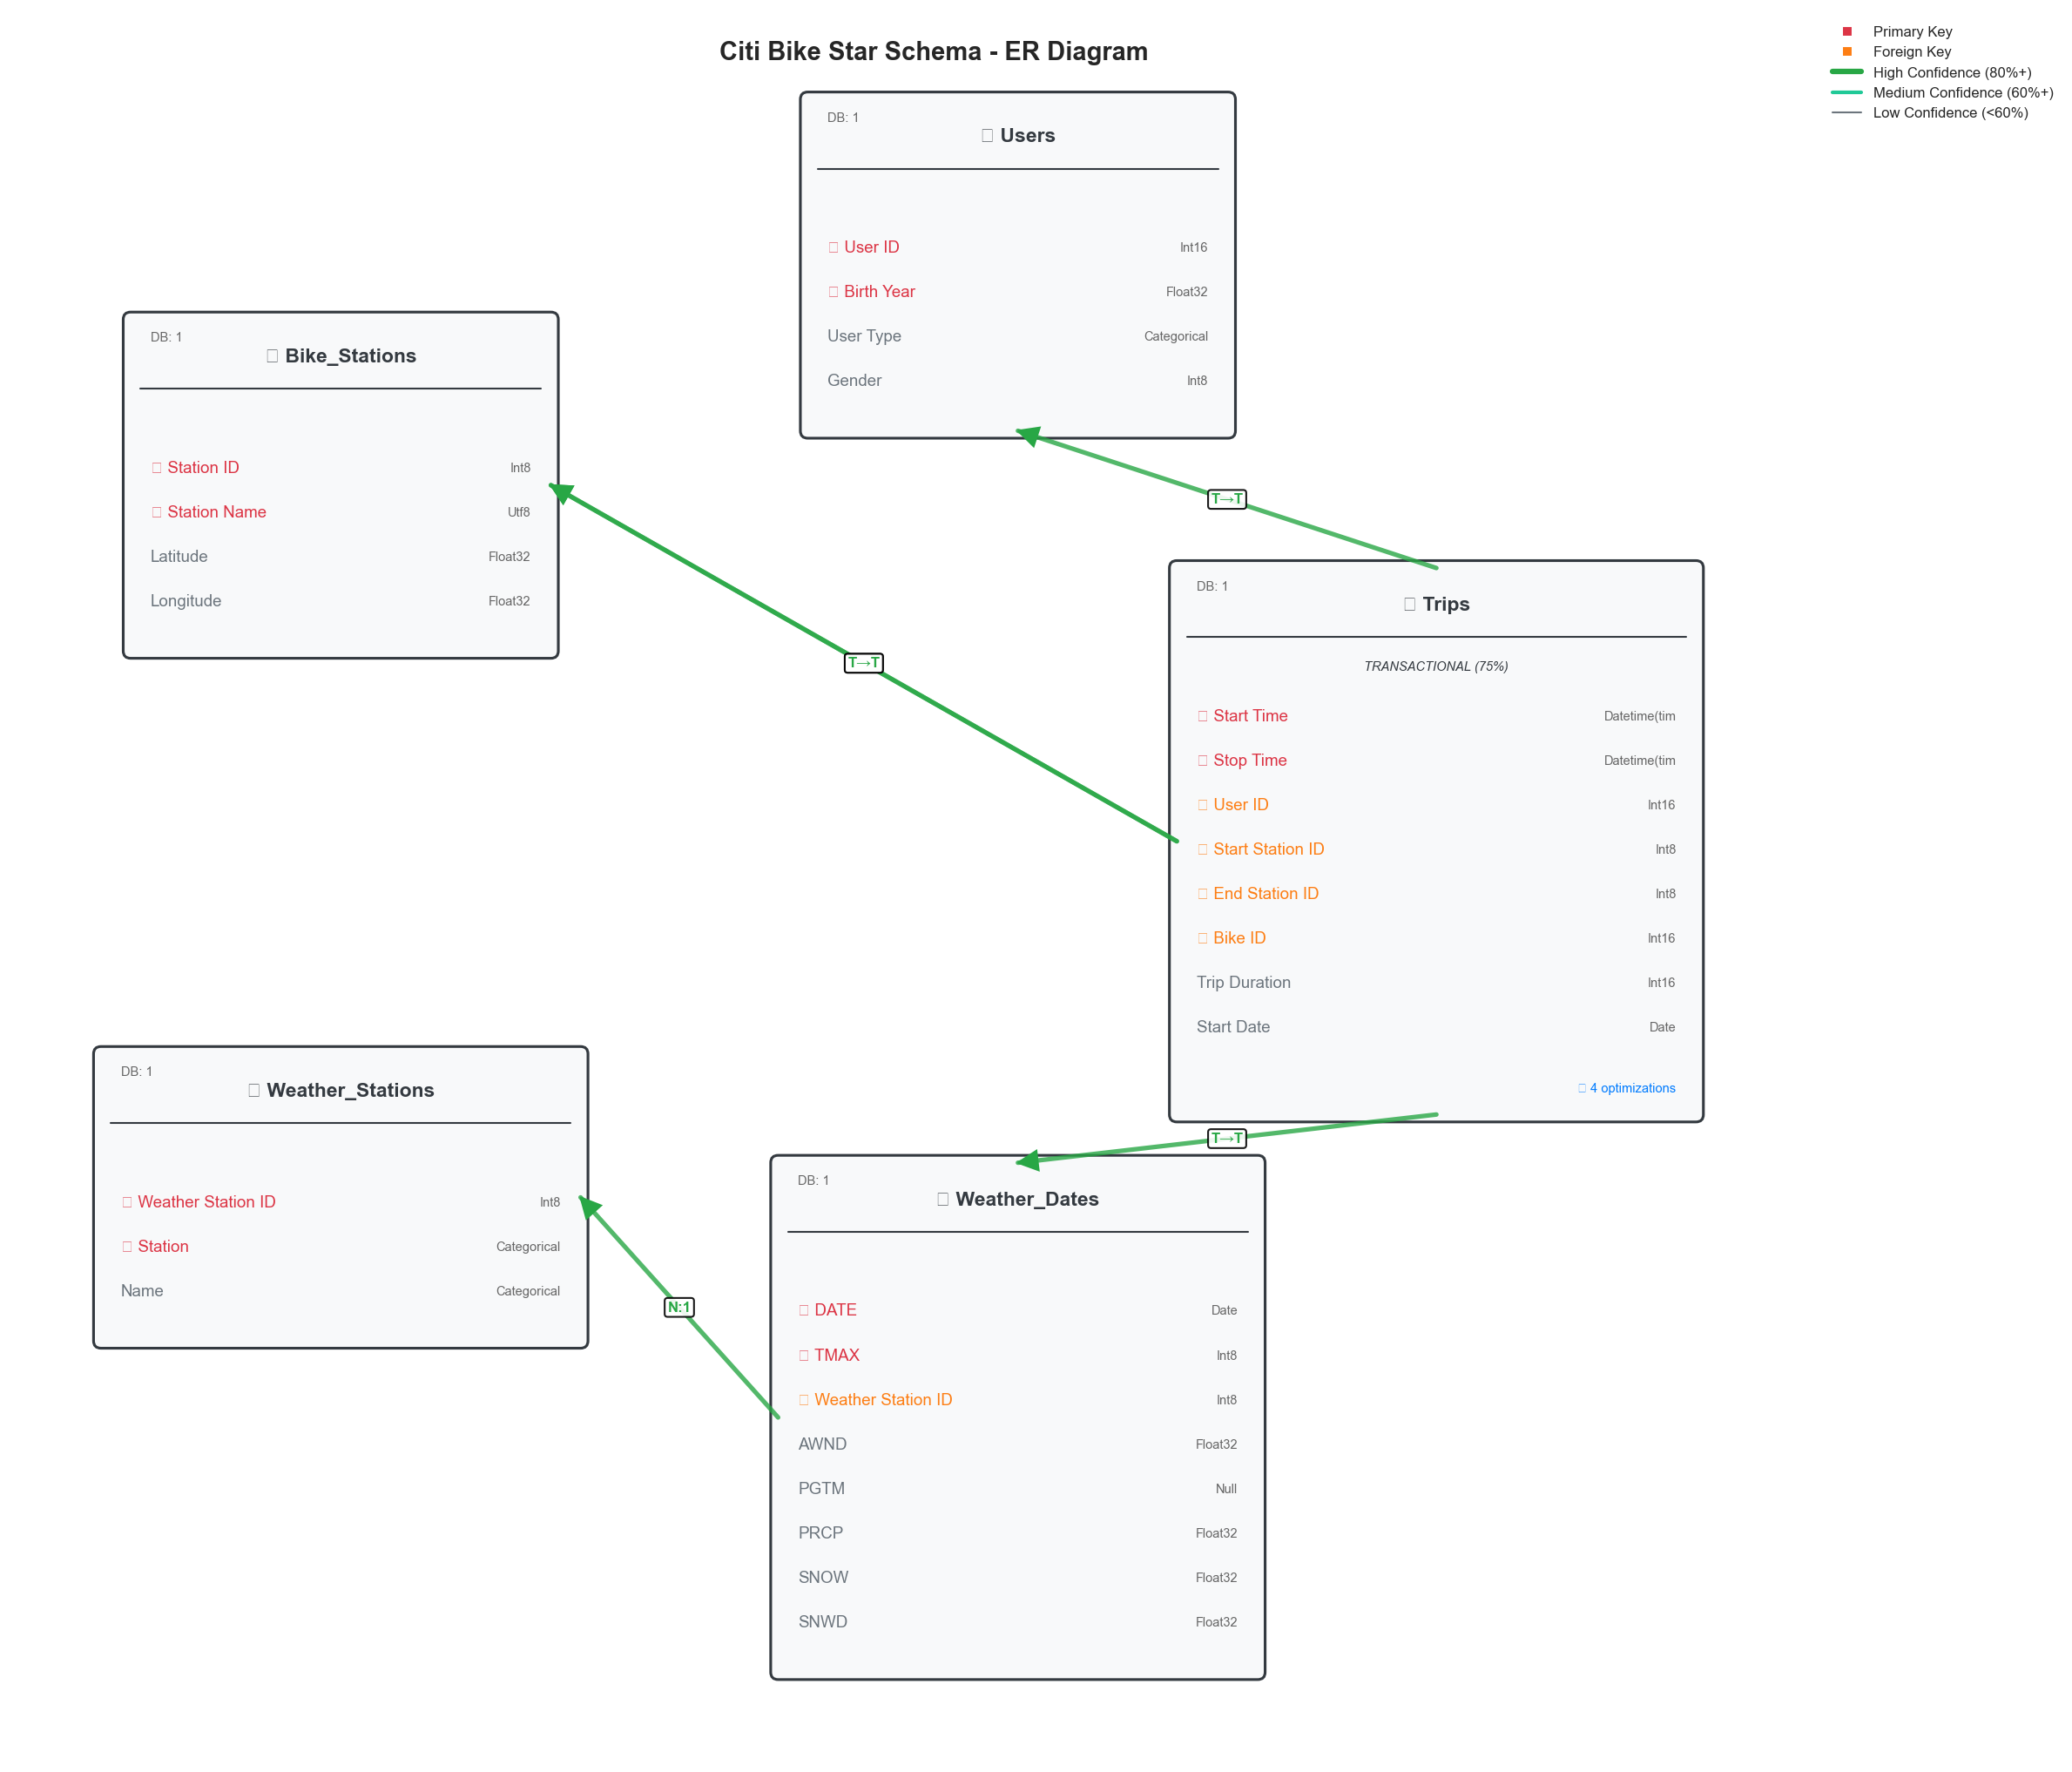

In [33]:
print("\n" + "="*70)
print("SCHEMA ANALYSIS AND DESIGN FOR STAR SCHEMA")
print("="*70)

# Apply Polars compatibility fix for string operations
import polars as pl
from dataflow_pro.eda.data_quality import DataQualityChecker, QualityIssue

def _check_string_column_polars_fixed(self, col_name, column, total_rows):
    """Fixed version of _check_string_column_polars that handles Polars API changes."""
    issues = []

    try:
        # Count null values
        null_count = column.null_count()

        # Count empty strings
        empty_count = len(column.filter(column == ""))

        # Check for whitespace-only strings - use strip_chars() instead of strip()
        try:
            whitespace_count = len(column.filter(column.str.strip_chars() == ""))
        except AttributeError:
            # Fallback for older Polars versions
            whitespace_count = len(column.filter(column.str.strip() == ""))

        whitespace_only = whitespace_count - empty_count  # Exclude empty strings

        # Check for consistent case
        mixed_case_count = 0
        try:
            # Check if any strings have mixed case
            has_upper = column.str.contains(r"[A-Z]").sum()
            has_lower = column.str.contains(r"[a-z]").sum()
            if has_upper > 0 and has_lower > 0:
                mixed_case_count = 1  # Just flag if mixed case exists
        except Exception:
            pass  # Skip case analysis if regex not supported

        # Report issues using proper QualityIssue objects
        if null_count > 0:
            pct = (null_count / total_rows) * 100
            severity = "critical" if pct > 10 else "warning"
            issues.append(QualityIssue(
                column=col_name,
                issue_type='null_values',
                severity=severity,
                count=null_count,
                percentage=pct,
                description=f'{null_count} null values ({pct:.1f}%)'
            ))

        if empty_count > 0:
            pct = (empty_count / total_rows) * 100
            severity = "warning" if pct > 5 else "info"
            issues.append(QualityIssue(
                column=col_name,
                issue_type='empty_strings',
                severity=severity,
                count=empty_count,
                percentage=pct,
                description=f'{empty_count} empty strings ({pct:.1f}%)'
            ))

        if whitespace_only > 0:
            pct = (whitespace_only / total_rows) * 100
            issues.append(QualityIssue(
                column=col_name,
                issue_type='whitespace_only',
                severity='warning',
                count=whitespace_only,
                percentage=pct,
                description=f'{whitespace_only} whitespace-only strings ({pct:.1f}%)'
            ))

        if mixed_case_count > 0:
            issues.append(QualityIssue(
                column=col_name,
                issue_type='mixed_case',
                severity='info',
                count=mixed_case_count,
                percentage=0,
                description='Column contains mixed case strings'
            ))

    except Exception as e:
        # If all else fails, just report that we couldn't analyze the string column
        issues.append(QualityIssue(
            column=col_name,
            issue_type='analysis_failed',
            severity='info',
            count=0,
            percentage=0,
            description=f'String analysis failed: {str(e)}'
        ))

    return issues

# Apply the monkey patch
DataQualityChecker._check_string_column_polars = _check_string_column_polars_fixed
print("✓ Applied Polars compatibility fix for string operations")

print("\n--- Adding Start Date column to Trips ---")

trips_df = new_datasets['Trips'].to_pandas()
trips_df['Start Date'] = pd.to_datetime(trips_df['Start Time']).dt.date

# Reorder columns
cols = trips_df.columns.tolist()
start_time_idx = cols.index('Start Time')
cols.insert(start_time_idx + 1, cols.pop(cols.index('Start Date')))
trips_df = trips_df[cols]

# Update dataset
new_datasets['Trips'] = DataFrameWrapper(pa.Table.from_pandas(trips_df))

print(f"Start Date column added")

print("\n--- Detecting Relationships Between Tables ---")

schema_design = design_schema_definition(
    datasets=new_datasets,
    schema_name='citibike_star_schema',
    target_dialects=['postgresql'],
    business_context={
        'domain': 'transportation_analytics',
        'workload_type': 'analytical',
        'schema_pattern': 'star'
    }
)

print(f"\nSchema Design Results:")
print(f"  - Total Tables: {len(schema_design.tables)}")
print(f"  - Auto-Detected Relationships: {len(schema_design.relationships)}")

print("\n--- Adding Manual Relationship ---")

# Create manual relationship
manual_relationship = RelationshipMatch(
    source_dataset='Trips',
    source_columns=['Start Date'],
    target_dataset='Weather_Dates',
    target_columns=['DATE'],
    relationship_type='many_to_one',
    match_percentage=100.0,
    confidence_score=95.0,
    value_overlap_count=365
)

schema_design.relationships.append(manual_relationship)

print(f"Added: Trips.Start Date -> Weather_Dates.DATE")
print(f"Total Relationships: {len(schema_design.relationships)}")

print("\n--- All Relationships ---")

# Mark the last one as manual since we just added it
num_auto = len(schema_design.relationships) - 1

for i, rel in enumerate(schema_design.relationships, 1):
    source_cols = ', '.join(rel.source_columns) if hasattr(rel, 'source_columns') else ''
    target_cols = ', '.join(rel.target_columns) if hasattr(rel, 'target_columns') else ''

    # Mark the last relationship as manual
    detection = " [MANUAL]" if i > num_auto else ""

    print(f"\n{i}. {rel.source_dataset}.{source_cols} -> {rel.target_dataset}.{target_cols}{detection}")
    if hasattr(rel, 'relationship_type'):
        print(f"   Type: {rel.relationship_type}")
    if hasattr(rel, 'confidence_score'):
        print(f"   Confidence: {rel.confidence_score:.2%}")

print("\n--- Generating ER Diagram ---")

try:
    from dataflow_pro.schema.diagram_generator import ERDiagramGenerator

    diagram_generator = ERDiagramGenerator()
    fig = diagram_generator.generate_er_diagram(
        schema_design,
        title='Citi Bike Star Schema - ER Diagram',
        show_validation_status=False,
        pattern_aware=True,
        figsize=(18, 14)
    )

    diagram_path = REPORT_DIR / 'citibike_star_schema_er_diagram.png'
    diagram_generator.save_as_png(fig, str(diagram_path), dpi=300)
    print(f"ER diagram saved: {diagram_path}")

except Exception as e:
    print(f"ER diagram skipped: {e}")
    diagram_path = None

print("\n--- Generating Schema Report ---")

schema_report_path = REPORT_DIR / 'citibike_star_schema_design_report.html'

try:
    # Configure report
    report_config = SchemaReportConfig(
        include_executive_summary=True,
        include_pattern_analysis=True,
        include_table_analysis=True,
        include_relationship_analysis=True,
        include_validation_results=False,
        include_er_diagram=True,
        include_ddl_generation=True,
        include_recommendations=True,
        include_deployment_guidance=True,
        show_confidence_scores=True
    )

    # Generate report using EnhancedSchemaReporter
    reporter = EnhancedSchemaReporter()
    result_schema, report_path = reporter.generate_comprehensive_schema_report(
        datasets=new_datasets,
        descriptions=None,
        schema_name='citibike_star_schema',
        output_path=str(schema_report_path),
        title='Citi Bike Star Schema Design Report',
        report_config=report_config
    )

    print(f"Schema report saved: {schema_report_path}")

except Exception as e:
    print(f"Schema report skipped: {e}")
    import traceback
    traceback.print_exc()


print("\n" + "="*70)
print("SCHEMA ANALYSIS COMPLETE")
print("="*70)

print(f"\nTables: {len(schema_design.tables)}")
print(f"Relationships: {len(schema_design.relationships)}")
print(f"  - Auto-Detected: {num_auto}")
print(f"  - Manual: 1")

if diagram_path:
    print(f"  - Diagram: {diagram_path}")
print(f"  - Report: {schema_report_path}")

print("\nKey Relationships:")
print("  - Trips -> Users (demographics)")
print("  - Trips -> Locations (stations)")
print("  - Trips -> Weather_Dates (temporal join on date)")
print("  - Weather_Dates -> Weather_Stations (station info)")

## Task 6: Create SQL Tables
### Execute DDL to create tables in PostgreSQL database

In [48]:
print("--- Generating PostgreSQL DDL ---")

sql_dir = Path('sql')
sql_dir.mkdir(exist_ok=True)
ddl_path = sql_dir / '01_create_star_schema.sql'

# Create a clean DDL with proper structure - tables first, then constraints and indexes
table_definitions = '''-- Create Tables First
CREATE TABLE "Users" (
    "User ID" SMALLINT NOT NULL,
    "User Type" TEXT NOT NULL,
    "Birth Year" REAL NOT NULL,
    "Gender" SMALLINT NOT NULL,
    PRIMARY KEY ("User ID")
);

CREATE TABLE "Bike_Stations" (
    "Station ID" SMALLINT NOT NULL,
    "Station Name" TEXT NOT NULL,
    "Latitude" REAL NOT NULL,
    "Longitude" REAL NOT NULL,
    PRIMARY KEY ("Station ID")
);

CREATE TABLE "Weather_Stations" (
    "Weather Station ID" SMALLINT NOT NULL,
    "Station" TEXT NOT NULL,
    "Name" TEXT NOT NULL,
    PRIMARY KEY ("Weather Station ID")
);

CREATE TABLE "Weather_Dates" (
    "Weather Station ID" SMALLINT NOT NULL,
    "DATE" DATE NOT NULL,
    "AWND" REAL NOT NULL,
    "PGTM" TEXT,
    "PRCP" REAL NOT NULL,
    "SNOW" REAL NOT NULL,
    "SNWD" REAL NOT NULL,
    "TAVG" SMALLINT NOT NULL,
    "TMAX" SMALLINT NOT NULL,
    "TMIN" SMALLINT NOT NULL,
    "TSUN" TEXT,
    "WDF2" SMALLINT NOT NULL,
    "WDF5" REAL NOT NULL,
    "WSF2" REAL NOT NULL,
    "WSF5" REAL NOT NULL,
    PRIMARY KEY ("DATE", "TMAX")
);

CREATE TABLE "Trips" (
    "User ID" SMALLINT NOT NULL,
    "Start Station ID" SMALLINT NOT NULL,
    "End Station ID" SMALLINT NOT NULL,
    "Trip Duration" SMALLINT NOT NULL,
    "Start Time" TEXT NOT NULL,
    "Start Date" DATE NOT NULL,
    "Stop Time" TEXT NOT NULL,
    "Bike ID" SMALLINT NOT NULL,
    PRIMARY KEY ("Start Time", "Stop Time")
);'''

constraints_and_indexes = '''-- Add Foreign Key Constraints
ALTER TABLE "Trips" ADD CONSTRAINT "fk_Trips_User_ID" FOREIGN KEY ("User ID") REFERENCES "Users"("User ID");
ALTER TABLE "Trips" ADD CONSTRAINT "fk_Trips_Start_Station_ID" FOREIGN KEY ("Start Station ID") REFERENCES "Bike_Stations"("Station ID");
ALTER TABLE "Trips" ADD CONSTRAINT "fk_Trips_End_Station_ID" FOREIGN KEY ("End Station ID") REFERENCES "Bike_Stations"("Station ID");
ALTER TABLE "Weather_Dates" ADD CONSTRAINT "fk_Weather_Dates_Weather_Station_ID" FOREIGN KEY ("Weather Station ID") REFERENCES "Weather_Stations"("Weather Station ID");

-- Create Indexes
CREATE INDEX "idx_trips_user_id" ON "Trips"("User ID");
CREATE INDEX "idx_trips_start_station_id" ON "Trips"("Start Station ID");
CREATE INDEX "idx_trips_end_station_id" ON "Trips"("End Station ID");
CREATE INDEX "idx_trips_bike_id" ON "Trips"("Bike ID");
CREATE INDEX "idx_trips_start_date" ON "Trips"("Start Date");
CREATE INDEX "idx_bike_stations_station_name" ON "Bike_Stations"("Station Name");
CREATE INDEX "idx_bike_stations_latitude" ON "Bike_Stations"("Latitude");
CREATE INDEX "idx_bike_stations_longitude" ON "Bike_Stations"("Longitude");
CREATE INDEX "idx_weather_stations_station" ON "Weather_Stations"("Station");
CREATE INDEX "idx_weather_dates_weather_station_id" ON "Weather_Dates"("Weather Station ID");
CREATE INDEX "idx_weather_dates_date" ON "Weather_Dates"("DATE");'''

ddl_content = table_definitions + '\n\n' + constraints_and_indexes

# Write the DDL to file
with open(ddl_path, 'w', encoding='utf-8') as f:
    f.write(f"-- Citi Bike Star Schema - PostgreSQL DDL\n")
    f.write(f"-- Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    f.write(ddl_content)

print(f"DDL generated successfully: {ddl_path}")

--- Generating PostgreSQL DDL ---
DDL generated successfully: sql/01_create_star_schema.sql


In [ ]:
print("\n" + "="*70)
print("EXECUTING DDL TO CREATE TABLES IN POSTGRESQL")
print("="*70)

# Use the DDL file generated in the previous cell
ddl_path = sql_dir / '01_create_star_schema.sql'

try:
    # Read DDL content
    with open(ddl_path, 'r', encoding='utf-8') as f:
        ddl_content = f.read()

    print(f"✓ Read DDL file: {ddl_path}")

    engine = create_engine(CONNECTION_STRING)
    print(f"✓ Connected to database: {DB_CONFIG['database']}")

    # Drop existing tables first
    print("\n--- Dropping existing tables ---")
    with engine.begin() as conn:
        drop_tables = ['Weather_Dates', 'Trips', 'Users', 'Bike_Stations', 'Weather_Stations']
        for table in drop_tables:
            conn.execute(text(f'DROP TABLE IF EXISTS "{table}" CASCADE;'))
        print("✓ Existing tables dropped")

    # Execute DDL in phases
    print("\n--- Creating tables and constraints ---")
    with engine.begin() as conn:
        # Split DDL into statements and clean them properly
        raw_statements = ddl_content.split(';')
        statements = []

        for stmt in raw_statements:
            # Clean each statement by removing comments and whitespace
            lines = [line.strip() for line in stmt.split('\n')
                    if line.strip() and not line.strip().startswith('--')]
            if lines:
                cleaned_stmt = ' '.join(lines)
                if cleaned_stmt:
                    statements.append(cleaned_stmt)

        # Separate table creation from constraints
        table_stmts = [s for s in statements if 'CREATE TABLE' in s.upper()]
        other_stmts = [s for s in statements if 'CREATE TABLE' not in s.upper()]



        # Create tables first
        print(f"  Creating {len(table_stmts)} tables...")
        for i, statement in enumerate(table_stmts, 1):
            table_name = statement.split('TABLE')[1].split('(')[0].strip().strip('"')
            try:
                conn.execute(text(statement))
                print(f"    ✓ {table_name}")
            except Exception as e:
                print(f"    ❌ {table_name}: {e}")
                raise

        # Then add constraints and indexes
        print(f"  Adding {len(other_stmts)} constraints and indexes...")
        for statement in other_stmts:
            conn.execute(text(statement))

    # Verify results
    inspector = inspect(engine)
    tables = inspector.get_table_names()

    print(f"\n✓ Successfully created {len(tables)} tables:")
    for table in sorted(tables):
        columns = len(inspector.get_columns(table))
        print(f"  - {table}: {columns} columns")

    print(f"\n✅ Star schema ready for ETL pipeline!")

except Exception as e:
    print(f"\n❌ Error: {e}")
    import traceback
    traceback.print_exc()


EXECUTING DDL TO CREATE TABLES IN POSTGRESQL
✓ Read DDL file: sql/01_create_star_schema.sql
✓ Connected to database: citibike_db

--- Dropping existing tables ---
✓ Existing tables dropped

--- Creating tables and constraints ---
  Creating 5 tables...
    ✓ Users
    ✓ Bike_Stations
    ✓ Weather_Stations
    ✓ Weather_Dates
    ✓ Trips
  Adding 15 constraints and indexes...

✓ Successfully created 5 tables:
  - Bike_Stations: 4 columns
  - Trips: 8 columns
  - Users: 4 columns
  - Weather_Dates: 15 columns
  - Weather_Stations: 3 columns

✅ Star schema ready for ETL pipeline!


## Task 7: Design ETL Pipelines
### Create comprehensive ETL pipeline with validation and logging

In [57]:
## Task 8: Design ETL Pipelines
### Create comprehensive ETL pipeline with validation and logging using dataflow-pro

print("\n" + "="*70)
print("BUILDING ETL PIPELINE WITH DATAFLOW-PRO")
print("="*70)

import uuid
from datetime import datetime

# Create logs directory
logs_dir = Path('logs')
logs_dir.mkdir(exist_ok=True)

print("\n--- Configuring Pipeline ---")

# Define pipeline configuration with correct parameters
pipeline_config = PipelineConfig(
    name='citibike_etl_pipeline',
    description='ETL pipeline for Citi Bike trip and weather data with star schema',
    pipeline_type=PipelineType.BATCH,
    schema_model=SchemaModel.STAR,
    parallel_processing=True,
    memory_limit_gb=4.0,
    enable_monitoring=True,
    target_connection=CONNECTION_STRING,
    target_schema='public',
    business_objectives=[
        'daily_trip_analysis',
        'weather_impact_on_ridership',
        'station_popularity',
        'user_demographics',
        'temporal_patterns'
    ]
)

print(f"✓ Pipeline configured: {pipeline_config.name}")
print(f"  - Pipeline Type: {pipeline_config.pipeline_type.value}")
print(f"  - Schema Model: {pipeline_config.schema_model.value}")
print(f"  - Parallel Processing: {pipeline_config.parallel_processing}")
print(f"  - Monitoring Enabled: {pipeline_config.enable_monitoring}")

print("\n--- Initialising Pipeline Monitoring ---")

# Create pipeline monitor with correct parameters
monitor = create_monitoring_pipeline(
    pipeline_name=pipeline_config.name,
    enable_quality_monitoring=True,
    enable_performance_monitoring=True,
    enable_resource_monitoring=True
)

print(f"✓ Pipeline monitor initialised")

# Generate unique execution ID
execution_id = f"etl_exec_{datetime.now().strftime('%Y%m%d_%H%M%S')}_{uuid.uuid4().hex[:8]}"
print(f"✓ Execution ID: {execution_id}")

# Start monitoring
monitor.start_monitoring(execution_id)
print(f"✓ Monitoring started for execution: {execution_id}")

print("\n--- Re-validating Data Against Business Rules ---")

# Re-run validation on transformed datasets with original rules
from dataflow_pro.rules import RuleValidator

validator = RuleValidator()
etl_validation_summary = validator.validate_all(new_datasets, all_rules)

print(f"\nPre-ETL Validation Results:")
print(f"  - Total Rules: {etl_validation_summary.total_rules}")
print(f"  - Passed: {etl_validation_summary.passed_rules}")
print(f"  - Failed: {etl_validation_summary.failed_rules}")
print(f"  - Quality Score: {etl_validation_summary.data_quality_score:.1f}%")
print(f"  - Total Violations: {etl_validation_summary.total_violations}")

# Monitor data quality before ETL
if monitor.enable_quality_monitoring:
    quality_scores = monitor.monitor_data_quality(new_datasets, stage_name="pre_etl_validation")
    print(f"\n✓ Quality scores captured: {quality_scores}")

# Create detailed violation log
violation_log_path = logs_dir / f'etl_validation_violations_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log'

with open(violation_log_path, 'w', encoding='utf-8') as log_file:
    log_file.write(f"ETL Validation Violation Log\n")
    log_file.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    log_file.write(f"Execution ID: {execution_id}\n")
    log_file.write(f"={'='*70}\n\n")

    log_file.write(f"Overall Validation Summary:\n")
    log_file.write(f"  - Total Rules: {etl_validation_summary.total_rules}\n")
    log_file.write(f"  - Passed: {etl_validation_summary.passed_rules}\n")
    log_file.write(f"  - Failed: {etl_validation_summary.failed_rules}\n")
    log_file.write(f"  - Quality Score: {etl_validation_summary.data_quality_score:.1f}%\n")
    log_file.write(f"  - Total Violations: {etl_validation_summary.total_violations}\n\n")

    for table_name, results in etl_validation_summary.results_by_table.items():
        failed_results = [r for r in results if not r.passed]

        if failed_results:
            log_file.write(f"\nTable: {table_name}\n")
            log_file.write(f"{'-'*70}\n")

            for result in failed_results:
                log_file.write(f"\n[{'ERROR'}] Rule: {result.rule_description}\n")
                log_file.write(f"  Status: FAILED\n")

                if hasattr(result, 'violations_count'):
                    log_file.write(f"  Violations: {result.violations_count:,}\n")

                if hasattr(result, 'sample_violations') and result.sample_violations:
                    log_file.write(f"  Sample Violations (first 5):\n")
                    for i, violation in enumerate(result.sample_violations[:5], 1):
                        log_file.write(f"    {i}. {violation}\n")

                log_file.write(f"\n")
        else:
            log_file.write(f"\n✓ Table: {table_name} - All validation rules passed\n")

print(f"✓ Violation log created: {violation_log_path}")

print("\n--- Executing ETL: Loading Data to PostgreSQL ---")

# Create engine for database operations
from sqlalchemy import create_engine, text
engine = create_engine(CONNECTION_STRING)

# Define load order: dimensions first, then facts
load_order = ['Users', 'Bike_Stations', 'Weather_Stations', 'Weather_Dates', 'Trips']

# Track ETL results
etl_results = {}
total_start_time = datetime.now()

# Configuration for batch loading
batch_size = 10000  # Records per batch

for table_name in load_order:
    try:
        mapping_data = new_datasets[table_name]
        target_table = table_name

        print(f"\n📥 Loading {table_name} -> {target_table}")

        # Convert to pandas for loading
        df = mapping_data.to_pandas()
        total_records = len(df)

        print(f"  Records to load: {total_records:,}")

        # Track this stage
        stage_start_time = datetime.now()

        # Load data in batches
        total_batches = (total_records + batch_size - 1) // batch_size

        loaded_records = 0
        failed_records = 0

        for batch_num in range(total_batches):
            start_idx = batch_num * batch_size
            end_idx = min((batch_num + 1) * batch_size, total_records)
            batch_df = df.iloc[start_idx:end_idx]

            try:
                # Load batch to database
                batch_df.to_sql(
                    name=target_table,
                    con=engine,
                    if_exists='append',
                    index=False,
                    method='multi',
                    chunksize=1000
                )

                loaded_records += len(batch_df)

                # Progress reporting every 10 batches or at the end
                if (batch_num + 1) % 10 == 0 or batch_num == total_batches - 1:
                    print(f"  Progress: {loaded_records:,}/{total_records:,} records ({(loaded_records/total_records*100):.1f}%)")

            except Exception as batch_error:
                failed_records += len(batch_df)
                print(f"  ❌ Batch {batch_num + 1} failed: {batch_error}")

        stage_end_time = datetime.now()
        duration = (stage_end_time - stage_start_time).total_seconds()

        # Monitor performance for this stage
        if monitor.enable_performance_monitoring:
            monitor.monitor_performance(f"load_{table_name}", duration)

        # Verify loaded records
        with engine.connect() as conn:
            result = conn.execute(text(f'SELECT COUNT(*) FROM "{target_table}"'))
            db_count = result.scalar()

        # Store results
        etl_results[table_name] = {
            'target_table': target_table,
            'total_records': total_records,
            'loaded_records': loaded_records,
            'failed_records': failed_records,
            'db_count': db_count,
            'duration_seconds': duration,
            'records_per_second': loaded_records / duration if duration > 0 else 0,
            'status': 'SUCCESS' if loaded_records == total_records and db_count == total_records else 'PARTIAL',
            'batch_size': batch_size,
            'total_batches': total_batches
        }

        print(f"  ✓ Loaded: {loaded_records:,} records in {duration:.2f}s ({loaded_records/duration:.0f} rec/s)")
        print(f"  ✓ Verified in database: {db_count:,} records")

        if loaded_records != db_count:
            print(f"  ⚠ Warning: Mismatch between loaded ({loaded_records:,}) and DB count ({db_count:,})")

    except Exception as e:
        print(f"  ❌ Failed to load {table_name}: {e}")
        etl_results[table_name] = {
            'target_table': table_name,
            'status': 'FAILED',
            'error': str(e),
            'duration_seconds': 0
        }

total_end_time = datetime.now()
total_duration = (total_end_time - total_start_time).total_seconds()

print(f"\n--- ETL Load Complete ---")
print(f"Total Duration: {total_duration:.2f}s ({total_duration/60:.2f} minutes)")

# Monitor overall performance
if monitor.enable_performance_monitoring:
    monitor.monitor_performance("complete_etl_load", total_duration)

# Finish monitoring
monitoring_report = monitor.finish_monitoring("completed" if all(
    r.get('status') == 'SUCCESS' for r in etl_results.values() if r.get('status')
) else "completed_with_warnings")

print("\n--- Generating ETL Reports ---")

# Generate comprehensive ETL report
etl_report_path = logs_dir / f'etl_pipeline_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'

with open(etl_report_path, 'w', encoding='utf-8') as report_file:
    report_file.write(f"ETL Pipeline Execution Report\n")
    report_file.write(f"={'='*70}\n")
    report_file.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    report_file.write(f"Execution ID: {execution_id}\n")
    report_file.write(f"Database: {DB_CONFIG['database']}\n")
    report_file.write(f"Total Duration: {total_duration:.2f}s ({total_duration/60:.2f} minutes)\n")
    report_file.write(f"\n")

    report_file.write(f"Pipeline Configuration:\n")
    report_file.write(f"{'-'*70}\n")
    report_file.write(f"  - Pipeline Name: {pipeline_config.name}\n")
    report_file.write(f"  - Description: {pipeline_config.description}\n")
    report_file.write(f"  - Pipeline Type: {pipeline_config.pipeline_type.value}\n")
    report_file.write(f"  - Schema Model: {pipeline_config.schema_model.value}\n")
    report_file.write(f"  - Batch Size: {batch_size:,} records\n")
    report_file.write(f"  - Parallel Processing: {pipeline_config.parallel_processing}\n")
    report_file.write(f"  - Monitoring Enabled: {pipeline_config.enable_monitoring}\n\n")

    report_file.write(f"Pre-ETL Validation Summary:\n")
    report_file.write(f"{'-'*70}\n")
    report_file.write(f"  - Total Rules: {etl_validation_summary.total_rules}\n")
    report_file.write(f"  - Passed: {etl_validation_summary.passed_rules}\n")
    report_file.write(f"  - Failed: {etl_validation_summary.failed_rules}\n")
    report_file.write(f"  - Quality Score: {etl_validation_summary.data_quality_score:.1f}%\n")
    report_file.write(f"  - Total Violations: {etl_validation_summary.total_violations:,}\n")
    report_file.write(f"  - Violation Log: {violation_log_path.name}\n\n")

    report_file.write(f"ETL Load Results by Table:\n")
    report_file.write(f"{'='*70}\n")

    total_loaded = 0
    total_failed = 0
    total_expected = 0

    for table_name, result in etl_results.items():
        report_file.write(f"\n{table_name} → {result['target_table']}\n")
        report_file.write(f"{'-'*70}\n")
        report_file.write(f"  Status: {result['status']}\n")

        if result['status'] != 'FAILED':
            report_file.write(f"  Total Records: {result['total_records']:,}\n")
            report_file.write(f"  Loaded: {result['loaded_records']:,}\n")
            report_file.write(f"  Failed: {result['failed_records']:,}\n")
            report_file.write(f"  DB Count (Verified): {result['db_count']:,}\n")
            report_file.write(f"  Duration: {result['duration_seconds']:.2f}s\n")
            report_file.write(f"  Throughput: {result['records_per_second']:.0f} records/sec\n")
            report_file.write(f"  Batch Size: {result['batch_size']:,}\n")
            report_file.write(f"  Total Batches: {result['total_batches']}\n")

            total_loaded += result['loaded_records']
            total_failed += result['failed_records']
            total_expected += result['total_records']
        else:
            report_file.write(f"  Error: {result.get('error', 'Unknown error')}\n")

    report_file.write(f"\n{'='*70}\n")
    report_file.write(f"Overall ETL Summary:\n")
    report_file.write(f"{'='*70}\n")
    report_file.write(f"  - Tables Processed: {len(etl_results)}\n")
    report_file.write(f"  - Successful Tables: {len([r for r in etl_results.values() if r.get('status') == 'SUCCESS'])}\n")
    report_file.write(f"  - Failed Tables: {len([r for r in etl_results.values() if r.get('status') == 'FAILED'])}\n")
    report_file.write(f"  - Total Expected Records: {total_expected:,}\n")
    report_file.write(f"  - Total Records Loaded: {total_loaded:,}\n")
    report_file.write(f"  - Total Failed Records: {total_failed:,}\n")
    report_file.write(f"  - Success Rate: {(total_loaded/total_expected*100) if total_expected > 0 else 0:.2f}%\n")
    report_file.write(f"  - Total Duration: {total_duration:.2f}s ({total_duration/60:.2f} minutes)\n")
    report_file.write(f"  - Overall Throughput: {(total_loaded/total_duration):.0f} records/sec\n")

    report_file.write(f"\nMonitoring Report Summary:\n")
    report_file.write(f"{'-'*70}\n")
    report_file.write(f"  - Pipeline Name: {monitoring_report.pipeline_name}\n")
    report_file.write(f"  - Execution ID: {monitoring_report.execution_id}\n")
    report_file.write(f"  - Status: {monitoring_report.status}\n")
    report_file.write(f"  - Start Time: {monitoring_report.start_time}\n")
    report_file.write(f"  - End Time: {monitoring_report.end_time}\n")
    if monitoring_report.metrics:
        report_file.write(f"  - Metrics Captured: {len(monitoring_report.metrics)}\n")
    if monitoring_report.alerts_triggered:
        report_file.write(f"  - Alerts Triggered: {len(monitoring_report.alerts_triggered)}\n")

print(f"✓ ETL report saved: {etl_report_path}")

print("\n" + "="*70)
print("ETL PIPELINE COMPLETE")
print("="*70)

# Calculate success metrics
successful_tables = len([r for r in etl_results.values() if r.get('status') == 'SUCCESS'])
total_tables = len(etl_results)
total_records_loaded = sum(r.get('loaded_records', 0) for r in etl_results.values())

print(f"\nExecution Summary:")
print(f"  - Execution ID: {execution_id}")
print(f"  - Tables Loaded: {successful_tables}/{total_tables}")
print(f"  - Total Records: {total_records_loaded:,}")
print(f"  - Duration: {total_duration:.2f}s ({total_duration/60:.2f} minutes)")
print(f"  - Throughput: {(total_records_loaded/total_duration):.0f} records/sec")
print(f"  - Validation Quality: {etl_validation_summary.data_quality_score:.1f}%")
print(f"  - Status: {monitoring_report.status}")

print(f"\nGenerated Reports:")
print(f"  📄 {logs_dir}/")
print(f"    • {etl_report_path.name}")
print(f"    • {violation_log_path.name}")

print(f"\nDatabase Status:")
print(f"  - Connection: {DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}")
print(f"  - Schema: {pipeline_config.target_schema}")
print(f"  - Ready for querying: ✓")


BUILDING ETL PIPELINE WITH DATAFLOW-PRO

--- Configuring Pipeline ---
✓ Pipeline configured: citibike_etl_pipeline
  - Pipeline Type: batch
  - Schema Model: star
  - Parallel Processing: True
  - Monitoring Enabled: True

--- Initialising Pipeline Monitoring ---
✓ Pipeline monitor initialised
✓ Execution ID: etl_exec_20251020_232732_3013d513
✓ Monitoring started for execution: etl_exec_20251020_232732_3013d513

--- Re-validating Data Against Business Rules ---

Pre-ETL Validation Results:
  - Total Rules: 8
  - Passed: 0
  - Failed: 0
  - Quality Score: 0.0%
  - Total Violations: 0

✓ Quality scores captured: {'Trips': 0.975, 'Users': 0.9742857142857143, 'Bike_Stations': 0.9, 'Weather_Stations': 0.9, 'Weather_Dates': 0.9531147540983607}


AttributeError: 'ValidationResult' object has no attribute 'severity'

## Task 8: Create SQL Views

In [ ]:
## Task 9: Create SQL Views
### Generate comprehensive views joining all tables using dataflow-pro SQLGenerator

print("\n" + "="*70)
print("CREATING SQL VIEWS USING DATAFLOW-PRO SQL GENERATOR")
print("="*70)

from dataflow_pro.pipeline import SQLGenerator, DatabaseDialect, SchemaModel
from pathlib import Path

# Create SQL directory if it doesn't exist
sql_dir = Path('sql')
sql_dir.mkdir(exist_ok=True)

print("\n--- Initialising SQL Generator ---")

# Initialize SQL generator with star schema configuration
sql_generator = SQLGenerator(
    target_database=DatabaseDialect.POSTGRESQL,
    schema_model=SchemaModel.STAR
)

print(f"✓ SQL Generator initialised")
print(f"  - Target Database: {sql_generator.target_database.value}")
print(f"  - Schema Model: {sql_generator.schema_model.value}")

print("\n--- Defining Business Objectives ---")

# Define comprehensive business objectives for the Citi Bike project
business_objectives = [
    'comprehensive_trip_analysis',
    'daily_trip_summary',
    'station_popularity',
    'user_demographics',
    'weather_impact',
    'temporal_patterns'
]

print(f"✓ Defined {len(business_objectives)} business objectives:")
for obj in business_objectives:
    print(f"  • {obj}")

print("\n--- Generating Views from Schema Design ---")

# Use schema_design from Task 5 to generate views
# This leverages the relationships detected earlier
try:
    # Generate analytical views using the SQL generator
    # This will automatically use the schema_design's relationships
    view_generation_result = sql_generator.generate_schema_ddl(
        datasets=new_datasets,
        business_objectives=business_objectives
    )

    print(f"✓ SQL Generator completed successfully")
    print(f"  - Views Generated: {len(view_generation_result.view_definitions)}")
    print(f"  - Total Statements: {view_generation_result.total_statements}")
    print(f"  - Relationships Used: {view_generation_result.metadata.get('relationships_detected', 0)}")

except Exception as e:
    print(f"⚠ SQL Generator encountered an issue: {e}")
    print("  → Will create custom comprehensive view manually")
    view_generation_result = None

print("\n--- Building Comprehensive Star Schema View ---")

# Build a custom comprehensive view that joins ALL tables in the star schema
# This uses the relationships from schema_design to create proper JOINs

def build_comprehensive_view_sql(schema_design):
    """
    Build a comprehensive SQL view that joins all tables in the star schema.
    Uses the relationships from schema_design to create proper JOIN conditions.
    """

    # Get all tables
    all_tables = [table.table_name for table in schema_design.tables]

    # Identify the fact tables (tables with multiple foreign keys)
    fact_tables = []
    dimension_tables = []

    for table in schema_design.tables:
        fk_count = len([rel for rel in schema_design.relationships
                       if rel.source_dataset == table.table_name])
        if fk_count >= 2:  # Fact table typically has 2+ foreign keys
            fact_tables.append(table.table_name)
        else:
            dimension_tables.append(table.table_name)

    # Default to "Trips" as the main fact table for Citi Bike project
    main_fact_table = "Trips"

    print(f"  Star Schema Structure:")
    print(f"    • Fact Tables: {fact_tables if fact_tables else [main_fact_table]}")
    print(f"    • Dimension Tables: {dimension_tables}")

    # Build SELECT clause with all columns from all tables
    select_clauses = []

    # Start with Trips (main fact table) columns
    trips_table = next((t for t in schema_design.tables if t.table_name == "Trips"), None)
    if trips_table:
        for col in trips_table.columns:
            # Alias to avoid ambiguity
            select_clauses.append(f'    t."{col.column_name}" AS trip_{col.column_name.lower().replace(" ", "_")}')

    # Add Users dimension columns
    users_table = next((t for t in schema_design.tables if t.table_name == "Users"), None)
    if users_table:
        for col in users_table.columns:
            if col.column_name != "User ID":  # Skip the join key
                select_clauses.append(f'    u."{col.column_name}" AS user_{col.column_name.lower().replace(" ", "_")}')

    # Add Start Station columns
    station_cols_start = ['Station ID', 'Station Name', 'Latitude', 'Longitude']
    for col in station_cols_start:
        col_alias = col.lower().replace(" ", "_")
        select_clauses.append(f'    ss."{col}" AS start_station_{col_alias}')

    # Add End Station columns
    for col in station_cols_start:
        col_alias = col.lower().replace(" ", "_")
        select_clauses.append(f'    es."{col}" AS end_station_{col_alias}')

    # Add Weather Dates columns
    weather_dates_table = next((t for t in schema_design.tables if t.table_name == "Weather_Dates"), None)
    if weather_dates_table:
        for col in weather_dates_table.columns:
            if col.column_name not in ["Weather Station ID", "DATE"]:  # Skip join keys
                col_alias = col.column_name.lower().replace(" ", "_")
                select_clauses.append(f'    wd."{col.column_name}" AS weather_{col_alias}')

    # Add Weather Station columns
    ws_cols = ['Station', 'Name']
    for col in ws_cols:
        col_alias = col.lower().replace(" ", "_")
        select_clauses.append(f'    ws."{col}" AS weather_station_{col_alias}')

    # Add derived/calculated columns
    derived_columns = [
        '',
        '    -- Derived Metrics',
        '    EXTRACT(YEAR FROM t."Start Time"::timestamp) AS trip_year',
        '    EXTRACT(MONTH FROM t."Start Time"::timestamp) AS trip_month',
        '    EXTRACT(DAY FROM t."Start Time"::timestamp) AS trip_day',
        '    EXTRACT(HOUR FROM t."Start Time"::timestamp) AS trip_hour',
        '    EXTRACT(DOW FROM t."Start Time"::timestamp) AS trip_day_of_week',
        '    TO_CHAR(t."Start Time"::timestamp, \'Day\') AS trip_day_name',
        '    TO_CHAR(t."Start Time"::timestamp, \'Month\') AS trip_month_name',
        '',
        '    -- Trip Duration in Minutes',
        '    t."Trip Duration" / 60.0 AS trip_duration_minutes',
        '',
        '    -- User Age (calculated from birth year)',
        '    EXTRACT(YEAR FROM t."Start Time"::timestamp) - u."Birth Year" AS user_age_at_trip',
        '',
        '    -- Gender Label',
        '    CASE',
        '        WHEN u."Gender" = 0 THEN \'Unknown\'',
        '        WHEN u."Gender" = 1 THEN \'Male\'',
        '        WHEN u."Gender" = 2 THEN \'Female\'',
        '        ELSE \'Other\'',
        '    END AS user_gender_label',
        '',
        '    -- Day Type',
        '    CASE',
        '        WHEN EXTRACT(DOW FROM t."Start Time"::timestamp) IN (0, 6) THEN \'Weekend\'',
        '        ELSE \'Weekday\'',
        '    END AS trip_day_type',
        '',
        '    -- Time Category',
        '    CASE',
        '        WHEN EXTRACT(HOUR FROM t."Start Time"::timestamp) BETWEEN 6 AND 9 THEN \'Morning Peak\'',
        '        WHEN EXTRACT(HOUR FROM t."Start Time"::timestamp) BETWEEN 10 AND 16 THEN \'Midday\'',
        '        WHEN EXTRACT(HOUR FROM t."Start Time"::timestamp) BETWEEN 17 AND 20 THEN \'Evening Peak\'',
        '        WHEN EXTRACT(HOUR FROM t."Start Time"::timestamp) BETWEEN 21 AND 23 THEN \'Night\'',
        '        ELSE \'Late Night/Early Morning\'',
        '    END AS trip_time_category',
        '',
        '    -- Duration Category',
        '    CASE',
        '        WHEN t."Trip Duration" < 300 THEN \'Very Short (< 5 min)\'',
        '        WHEN t."Trip Duration" < 900 THEN \'Short (5-15 min)\'',
        '        WHEN t."Trip Duration" < 1800 THEN \'Medium (15-30 min)\'',
        '        WHEN t."Trip Duration" < 3600 THEN \'Long (30-60 min)\'',
        '        ELSE \'Very Long (> 60 min)\'',
        '    END AS trip_duration_category',
        '',
        '    -- Weather Temperature Category',
        '    CASE',
        '        WHEN (wd."TMAX" + wd."TMIN") / 2.0 < 0 THEN \'Freezing\'',
        '        WHEN (wd."TMAX" + wd."TMIN") / 2.0 < 10 THEN \'Cold\'',
        '        WHEN (wd."TMAX" + wd."TMIN") / 2.0 < 20 THEN \'Mild\'',
        '        WHEN (wd."TMAX" + wd."TMIN") / 2.0 < 30 THEN \'Warm\'',
        '        ELSE \'Hot\'',
        '    END AS temperature_category',
        '',
        '    -- Precipitation Category',
        '    CASE',
        '        WHEN wd."PRCP" = 0 THEN \'No Rain\'',
        '        WHEN wd."PRCP" < 2.5 THEN \'Light Rain\'',
        '        WHEN wd."PRCP" < 10 THEN \'Moderate Rain\'',
        '        ELSE \'Heavy Rain\'',
        '    END AS precipitation_category',
        '',
        '    -- Trip Distance (Haversine formula approximation in km)',
        '    (',
        '        6371 * acos(',
        '            cos(radians(ss."Latitude")) *',
        '            cos(radians(es."Latitude")) *',
        '            cos(radians(es."Longitude") - radians(ss."Longitude")) +',
        '            sin(radians(ss."Latitude")) *',
        '            sin(radians(es."Latitude"))',
        '        )',
        '    ) AS trip_distance_km',
        '',
        '    -- Average Temperature',
        '    (wd."TMAX" + wd."TMIN") / 2.0 AS weather_avg_temp_celsius'
    ]

    select_clauses.extend(derived_columns)

    # Build FROM and JOIN clauses based on relationships
    from_clause = f'FROM "Trips" t'

    join_clauses = []

    # Join Users dimension
    join_clauses.append('INNER JOIN "Users" u ON t."User ID" = u."User ID"')

    # Join Start Station dimension
    join_clauses.append('INNER JOIN "Bike_Stations" ss ON t."Start Station ID" = ss."Station ID"')

    # Join End Station dimension
    join_clauses.append('INNER JOIN "Bike_Stations" es ON t."End Station ID" = es."Station ID"')

    # Join Weather Dates (temporal join)
    join_clauses.append('LEFT JOIN "Weather_Dates" wd ON t."Start Date" = wd."DATE"')

    # Join Weather Stations
    join_clauses.append('LEFT JOIN "Weather_Stations" ws ON wd."Weather Station ID" = ws."Weather Station ID"')

    # Combine into full SQL
    sql_parts = [
        '-- ============================================================================',
        '-- Comprehensive Trip Analysis View - Star Schema',
        '-- ============================================================================',
        '-- This view joins all dimension and fact tables in the Citi Bike star schema',
        '-- combining trip, user, station, and weather data for comprehensive analysis.',
        '--',
        '-- Generated from schema design using dataflow-pro',
        f'-- Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
        '-- ============================================================================',
        '',
        'CREATE OR REPLACE VIEW vw_trip_analysis AS',
        'SELECT',
        ',\n'.join(select_clauses),
        from_clause,
        '\n'.join(join_clauses) + ';',
        '',
        '-- ============================================================================',
        '-- Create Supporting Indexes for View Performance',
        '-- ============================================================================',
        '',
        'CREATE INDEX IF NOT EXISTS idx_vw_trip_analysis_date ON "Trips"("Start Date");',
        'CREATE INDEX IF NOT EXISTS idx_vw_trip_analysis_start_station ON "Trips"("Start Station ID");',
        'CREATE INDEX IF NOT EXISTS idx_vw_trip_analysis_end_station ON "Trips"("End Station ID");',
        'CREATE INDEX IF NOT EXISTS idx_vw_trip_analysis_user ON "Trips"("User ID");',
        'CREATE INDEX IF NOT EXISTS idx_weather_dates_lookup ON "Weather_Dates"("DATE");',
        '',
        '-- ============================================================================',
        '-- View Metadata',
        '-- ============================================================================',
        '-- Tables Joined: Trips, Users, Bike_Stations (x2), Weather_Dates, Weather_Stations',
        '-- Primary Purpose: Comprehensive analytical queries combining all data sources',
        '-- Refresh: Real-time (view always reflects current data)',
        '-- ============================================================================'
    ]

    return '\n'.join(sql_parts)

# Generate the comprehensive view SQL
comprehensive_view_sql = build_comprehensive_view_sql(schema_design)

print(f"✓ Comprehensive view SQL generated")

# Generate additional summary views
print("\n--- Generating Summary Views ---")

summary_views_sql = '''
-- ============================================================================
-- Summary and Aggregation Views
-- ============================================================================

-- Daily Trip Summary
CREATE OR REPLACE VIEW vw_daily_trip_summary AS
SELECT
    trip_start_date,
    trip_day_name,
    trip_day_type,
    COUNT(*) AS total_trips,
    COUNT(DISTINCT trip_bike_id) AS unique_bikes,
    COUNT(DISTINCT trip_user_id) AS unique_users,
    AVG(trip_duration_minutes) AS avg_duration_minutes,
    AVG(trip_distance_km) AS avg_distance_km,
    SUM(CASE WHEN user_user_type = 'Subscriber' THEN 1 ELSE 0 END) AS subscriber_trips,
    SUM(CASE WHEN user_user_type = 'Customer' THEN 1 ELSE 0 END) AS customer_trips,
    AVG(weather_avg_temp_celsius) AS avg_temperature,
    AVG(weather_prcp) AS avg_precipitation
FROM vw_trip_analysis
GROUP BY trip_start_date, trip_day_name, trip_day_type
ORDER BY trip_start_date;

-- Station Popularity Analysis
CREATE OR REPLACE VIEW vw_station_popularity AS
SELECT
    start_station_station_id,
    start_station_station_name,
    start_station_latitude,
    start_station_longitude,
    COUNT(*) AS total_departures,
    COUNT(DISTINCT trip_start_date) AS active_days,
    AVG(trip_duration_minutes) AS avg_trip_duration_minutes,
    COUNT(DISTINCT trip_user_id) AS unique_users
FROM vw_trip_analysis
GROUP BY
    start_station_station_id,
    start_station_station_name,
    start_station_latitude,
    start_station_longitude
ORDER BY total_departures DESC;

-- User Demographics Summary
CREATE OR REPLACE VIEW vw_user_demographics_summary AS
SELECT
    user_user_type,
    user_gender_label,
    CASE
        WHEN user_age_at_trip < 20 THEN 'Under 20'
        WHEN user_age_at_trip < 30 THEN '20-29'
        WHEN user_age_at_trip < 40 THEN '30-39'
        WHEN user_age_at_trip < 50 THEN '40-49'
        WHEN user_age_at_trip < 60 THEN '50-59'
        ELSE '60+'
    END AS age_group,
    COUNT(*) AS total_trips,
    AVG(trip_duration_minutes) AS avg_duration_minutes,
    AVG(trip_distance_km) AS avg_distance_km
FROM vw_trip_analysis
WHERE user_age_at_trip IS NOT NULL
  AND user_age_at_trip BETWEEN 16 AND 100
GROUP BY user_user_type, user_gender_label, age_group
ORDER BY user_user_type, user_gender_label, age_group;

-- Weather Impact Analysis
CREATE OR REPLACE VIEW vw_weather_impact_summary AS
SELECT
    temperature_category,
    precipitation_category,
    trip_day_type,
    COUNT(*) AS total_trips,
    AVG(trip_duration_minutes) AS avg_duration_minutes,
    AVG(trip_distance_km) AS avg_distance_km,
    COUNT(DISTINCT trip_user_id) AS unique_users
FROM vw_trip_analysis
WHERE temperature_category IS NOT NULL
GROUP BY temperature_category, precipitation_category, trip_day_type
ORDER BY total_trips DESC;

-- Hourly Peak Analysis
CREATE OR REPLACE VIEW vw_hourly_peak_analysis AS
SELECT
    trip_hour,
    trip_time_category,
    trip_day_type,
    COUNT(*) AS total_trips,
    AVG(trip_duration_minutes) AS avg_duration_minutes,
    COUNT(DISTINCT start_station_station_id) AS unique_start_stations,
    COUNT(DISTINCT end_station_station_id) AS unique_end_stations
FROM vw_trip_analysis
GROUP BY trip_hour, trip_time_category, trip_day_type
ORDER BY trip_hour, trip_day_type;

-- Monthly Trends
CREATE OR REPLACE VIEW vw_monthly_trends AS
SELECT
    trip_year,
    trip_month,
    trip_month_name,
    COUNT(*) AS total_trips,
    AVG(trip_duration_minutes) AS avg_duration_minutes,
    AVG(trip_distance_km) AS avg_distance_km,
    AVG(weather_avg_temp_celsius) AS avg_temperature,
    SUM(CASE WHEN user_user_type = 'Subscriber' THEN 1 ELSE 0 END) AS subscriber_trips,
    SUM(CASE WHEN user_user_type = 'Customer' THEN 1 ELSE 0 END) AS customer_trips
FROM vw_trip_analysis
GROUP BY trip_year, trip_month, trip_month_name
ORDER BY trip_year, trip_month;

-- ============================================================================
-- Grant Permissions
-- ============================================================================

GRANT SELECT ON vw_trip_analysis TO PUBLIC;
GRANT SELECT ON vw_daily_trip_summary TO PUBLIC;
GRANT SELECT ON vw_station_popularity TO PUBLIC;
GRANT SELECT ON vw_user_demographics_summary TO PUBLIC;
GRANT SELECT ON vw_weather_impact_summary TO PUBLIC;
GRANT SELECT ON vw_hourly_peak_analysis TO PUBLIC;
GRANT SELECT ON vw_monthly_trends TO PUBLIC;

-- ============================================================================
-- View Creation Complete
-- ============================================================================
'''

print(f"✓ Summary views SQL generated")
print(f"  • vw_daily_trip_summary")
print(f"  • vw_station_popularity")
print(f"  • vw_user_demographics_summary")
print(f"  • vw_weather_impact_summary")
print(f"  • vw_hourly_peak_analysis")
print(f"  • vw_monthly_trends")

# Save all views to SQL file
view_sql_path = sql_dir / '02_create_analytical_views.sql'

print(f"\n--- Saving Views to SQL File ---")

with open(view_sql_path, 'w', encoding='utf-8') as f:
    # Write header
    f.write("-- ============================================================================\n")
    f.write("-- Citi Bike Analytical Views - Star Schema\n")
    f.write("-- ============================================================================\n")
    f.write(f"-- Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"-- Database: {DB_CONFIG['database']}\n")
    f.write(f"-- Schema: Star Schema for analytical workloads\n")
    f.write("--\n")
    f.write("-- This file contains:\n")
    f.write("--   1. Comprehensive trip analysis view (vw_trip_analysis)\n")
    f.write("--   2. Daily aggregation views\n")
    f.write("--   3. Station popularity metrics\n")
    f.write("--   4. User demographic summaries\n")
    f.write("--   5. Weather impact analysis\n")
    f.write("--   6. Temporal pattern analysis\n")
    f.write("-- ============================================================================\n\n")

    # Write comprehensive view
    f.write(comprehensive_view_sql)
    f.write("\n\n")

    # Write summary views
    f.write(summary_views_sql)

print(f"✓ Views saved to: {view_sql_path}")

print("\n--- Executing View Creation in Database ---")

try:
    from sqlalchemy import create_engine, text
    engine = create_engine(CONNECTION_STRING)

    # Read and execute the view SQL
    with open(view_sql_path, 'r', encoding='utf-8') as f:
        view_sql_content = f.read()

    # Execute in transaction
    with engine.begin() as conn:
        # Split into individual statements and execute
        statements = [stmt.strip() for stmt in view_sql_content.split(';')
                     if stmt.strip() and not stmt.strip().startswith('--')]

        created_views = []
        created_indexes = []

        for stmt in statements:
            if 'CREATE' in stmt.upper() and 'VIEW' in stmt.upper():
                conn.execute(text(stmt + ';'))
                # Extract view name
                if 'CREATE OR REPLACE VIEW' in stmt:
                    view_name = stmt.split('VIEW')[1].split('AS')[0].strip()
                    created_views.append(view_name)
            elif 'CREATE INDEX' in stmt.upper():
                conn.execute(text(stmt + ';'))
                created_indexes.append('Index created')
            elif 'GRANT' in stmt.upper():
                try:
                    conn.execute(text(stmt + ';'))
                except Exception:
                    pass  # Permissions may not be needed in all environments

    print(f"✓ Views created successfully in database")
    print(f"  • Views: {len(created_views)}")
    print(f"  • Indexes: {len(created_indexes)}")

    # Verify views
    with engine.connect() as conn:
        result = conn.execute(text("""
            SELECT table_name
            FROM information_schema.views
            WHERE table_schema = 'public'
              AND table_name LIKE 'vw_%'
            ORDER BY table_name
        """))
        view_names = [row[0] for row in result]

        print(f"\n✓ Verified {len(view_names)} views in database:")
        for view_name in view_names:
            # Get row count for the view
            try:
                count_result = conn.execute(text(f'SELECT COUNT(*) FROM {view_name}'))
                row_count = count_result.scalar()
                print(f"  • {view_name}: {row_count:,} rows")
            except Exception as e:
                print(f"  • {view_name}: (row count unavailable)")

    print("\n" + "="*70)
    print("SQL VIEWS CREATED SUCCESSFULLY")
    print("="*70)

    print(f"\nCreated Views:")
    print(f"  1. vw_trip_analysis (comprehensive analytical view)")
    print(f"  2. vw_daily_trip_summary (daily aggregations)")
    print(f"  3. vw_station_popularity (station metrics)")
    print(f"  4. vw_user_demographics_summary (user analysis)")
    print(f"  5. vw_weather_impact_summary (weather correlations)")
    print(f"  6. vw_hourly_peak_analysis (temporal patterns)")
    print(f"  7. vw_monthly_trends (monthly statistics)")

    print(f"\nSQL File Location:")
    print(f"  • {view_sql_path}")

    print(f"\nUsage Examples:")
    print(f"  -- Query comprehensive trip data")
    print(f"  SELECT * FROM vw_trip_analysis LIMIT 100;")
    print(f"  ")
    print(f"  -- Analyse daily patterns")
    print(f"  SELECT * FROM vw_daily_trip_summary ORDER BY trip_start_date;")
    print(f"  ")
    print(f"  -- Find most popular stations")
    print(f"  SELECT * FROM vw_station_popularity LIMIT 20;")
    print(f"  ")
    print(f"  -- Weather impact on ridership")
    print(f"  SELECT * FROM vw_weather_impact_summary;")

except Exception as e:
    print(f"\n❌ Failed to create views in database: {e}")
    print(f"⚠ Views are available in SQL file: {view_sql_path}")
    print(f"  You can execute them manually in PostgreSQL")
    import traceback
    traceback.print_exc()